In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
np.random.seed(42) # Для воспроизводимости
n=10000 # Количество клиентов

In [3]:
# Создаем данные
data = {
    'age': np.random.randint(18, 70, size=n),
    'experience_month': np.random.randint(0, 600, size=n),
    'incom_rub': np.random.randint(20000, 500000, size=n),
    'visit_count': np.random.randint(0, 10, size=n)
}

df = pd.DataFrame(data)

print("Исходные данные:\n", df)
print(df.describe()) 

Исходные данные:
       age  experience_month  incom_rub  visit_count
0      56               213     243524            9
1      69                23     259583            3
2      46               320     177781            4
3      32               273     127535            2
4      60               555      35063            4
...   ...               ...        ...          ...
9995   55               495      82335            1
9996   51               145     443735            8
9997   57               332     416926            9
9998   64               480      83564            1
9999   32               262     149257            3

[10000 rows x 4 columns]
                age  experience_month      incom_rub  visit_count
count  10000.000000      10000.000000   10000.000000  10000.00000
mean      43.539400        299.626000  258337.925200      4.56300
std       14.911636        173.843277  139316.969392      2.85721
min       18.000000          0.000000   20056.000000      0.00000
25

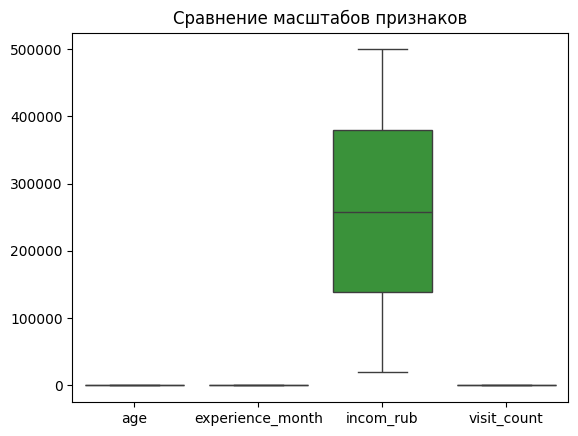

In [4]:
# Строим деаграмму размаха
sns.boxplot(data=df)

plt.title('Сравнение масштабов признаков')
plt.show()

In [5]:
# Разделение данных
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Выводим размеры выборок
print(f"Размер обучающей выборки: {train_df.shape}")
print(f"Размер тестовой выборки: {test_df.shape}") 

Размер обучающей выборки: (8000, 4)
Размер тестовой выборки: (2000, 4)


### Стандартизированое масштабирование

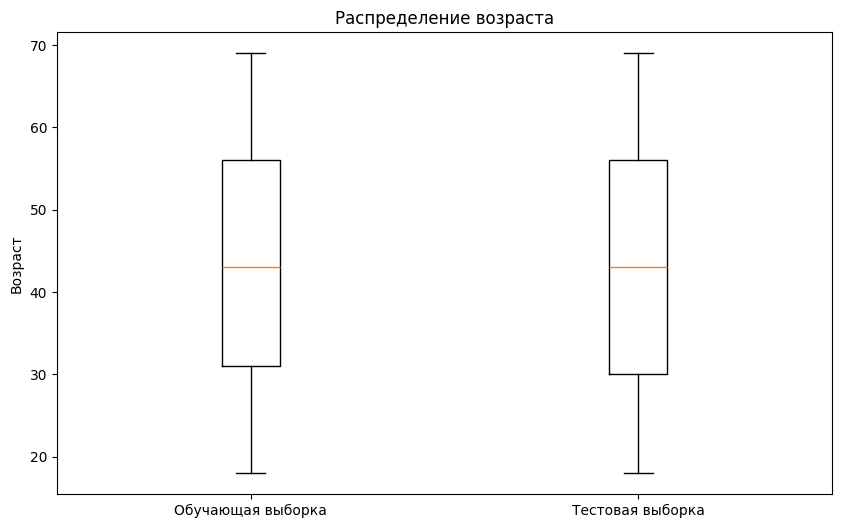

In [6]:
# Строим деаграмму размаха
plt.figure(figsize=(10,6))

plt.boxplot([train_df['age'], test_df['age']])

plt.title('Распределение возраста')
plt.ylabel('Возраст')
plt.xticks([1, 2], ['Обучающая выборка', 'Тестовая выборка'])
plt.show()

In [7]:
# Вычисляем среднее и стандартное отклонение по обучающей выборке
train_mean = train_df.mean()
train_std = train_df.std()

In [8]:
# Применяем стандартизацию
train_stdzd = (train_df - train_mean) / train_std
test_stdzd = (test_df - train_mean) / train_std

In [9]:
print("Сравнение статистик ДО и ПОСЛЕ стандартизации:\n")
for col in train_df.columns:
    original_min = train_df[col].min()
    original_max = train_df[col].max()
    original_mean = train_df[col].mean()
    
    standardized_min = train_stdzd[col].min()
    standardized_max = train_stdzd[col].max()
    standardized_mean = train_stdzd[col].mean()
    
    print(f"{col}:\n"
          f"  Было:    min={original_min:.2f}, max={original_max:.2f}, mean={original_mean:.2f}\n"
          f"  Стало:   min={standardized_min:.2f}, max={standardized_max:.2f}, mean={standardized_mean:.2f}\n")

Сравнение статистик ДО и ПОСЛЕ стандартизации:

age:
  Было:    min=18.00, max=69.00, mean=43.61
  Стало:   min=-1.72, max=1.70, mean=0.00

experience_month:
  Было:    min=0.00, max=599.00, mean=299.40
  Стало:   min=-1.72, max=1.72, mean=-0.00

incom_rub:
  Было:    min=20146.00, max=499869.00, mean=257584.23
  Стало:   min=-1.70, max=1.74, mean=-0.00

visit_count:
  Было:    min=0.00, max=9.00, mean=4.54
  Стало:   min=-1.59, max=1.56, mean=-0.00



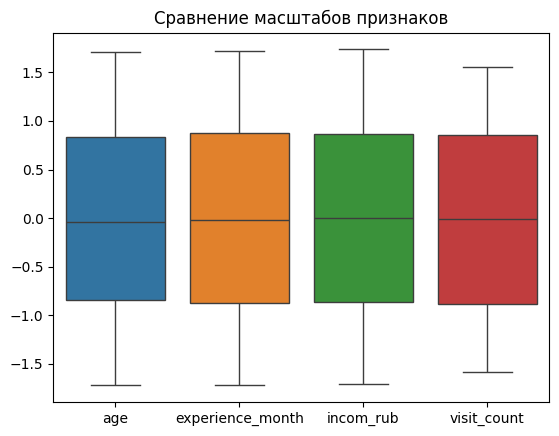

In [10]:
# Строим деаграмму размаха
sns.boxplot(data=train_stdzd)

plt.title('Сравнение масштабов признаков')
plt.show()

### Мини-макс (Min-Max) масштабирование

In [11]:
# Вычисляем минимум и максимум по обучающей выборке (правильно)
min_train = train_df.min()
max_train = train_df.max()

In [12]:
# Масштабируем данные с использованием параметров train
train_minmax = (train_df - min_train) / (max_train - min_train)
test_minmax = (test_df - min_train) / (max_train - min_train)

In [13]:
# Сравнение статистик ДО и ПОСЛЕ масштабирования
print("\nСравнение статистик ДО и ПОСЛЕ Min-Max нормализации:\n")
for col in train_df.columns:
    original_min = train_df[col].min()
    original_max = train_df[col].max()
    original_mean = train_df[col].mean()
    
    scaled_min = train_minmax[col].min()
    scaled_max = train_minmax[col].max()
    scaled_mean = train_minmax[col].mean()
    
    print(f"{col}:\n"
          f"  Было:    min={original_min:.2f}, max={original_max:.2f}, mean={original_mean:.2f}\n"
          f"  Стало:   min={scaled_min:.2f}, max={scaled_max:.2f}, mean={scaled_mean:.2f}\n")


Сравнение статистик ДО и ПОСЛЕ Min-Max нормализации:

age:
  Было:    min=18.00, max=69.00, mean=43.61
  Стало:   min=0.00, max=1.00, mean=0.50

experience_month:
  Было:    min=0.00, max=599.00, mean=299.40
  Стало:   min=0.00, max=1.00, mean=0.50

incom_rub:
  Было:    min=20146.00, max=499869.00, mean=257584.23
  Стало:   min=0.00, max=1.00, mean=0.49

visit_count:
  Было:    min=0.00, max=9.00, mean=4.54
  Стало:   min=0.00, max=1.00, mean=0.50



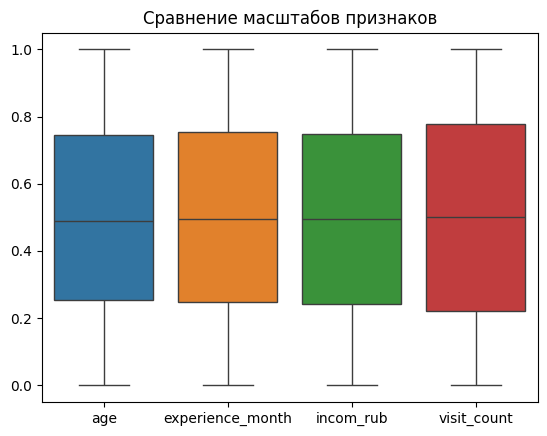

In [14]:
# Строим деаграмму размаха
sns.boxplot(data=train_minmax)

plt.title('Сравнение масштабов признаков')
plt.show()